# Assignment: Implement a Feedforward Neural Network and Backpropagation

**Dataset:** Breast Cancer Wisconsin Diagnostic dataset from Scikit-learn  
**Task type:** Binary classification  
**Required architecture:** $30 \rightarrow 16 \rightarrow 1$  
**Hidden activation:** ReLU  
**Output activation:** Sigmoid  
**Loss:** Binary cross-entropy  
**Optimizer:** Full-batch gradient descent  
**Total marks:** 20

The positive label is `1` (benign) in the original Scikit-learn dataset. State this clearly when interpreting precision and recall.

## Assignment rules

1. Use NumPy for Tasks 3–8;
2. Use a fixed random state so that results are reproducible.
3. Fit preprocessing only on the training data.
4. Use validation data for model decisions and use the test set only for final evaluation.
5. Keep every output visible in the submitted notebook.

# Task 1 — Load the Breast Cancer dataset and print its shape, feature names, target names, and class counts.

In [1]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

warnings.filterwarnings("ignore")
np.set_printoptions(precision=4, suppress=True)
RANDOM_STATE = 42

In [2]:
# Load Breast Cancer Wisconsin Diagnostic dataset
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target
feature_names = cancer.feature_names
target_names = cancer.target_names

print("=" * 80)
print("Task 1: Breast Cancer Wisconsin Diagnostic Dataset Inspection")
print("=" * 80)
print(f"Feature matrix shape (X) : {X.shape}")
print(f"Target vector shape (y)  : {y.shape}")
print(f"Number of samples        : {X.shape[0]}")
print(f"Number of features       : {X.shape[1]}")

Task 1: Breast Cancer Wisconsin Diagnostic Dataset Inspection
Feature matrix shape (X) : (569, 30)
Target vector shape (y)  : (569,)
Number of samples        : 569
Number of features       : 30


In [3]:
print("\nTarget Class Mapping and Counts:")
for idx, name in enumerate(target_names):
    count = int(np.sum(y == idx))
    prop = float(np.mean(y == idx) * 100)
    print(f"  Class {idx} -> {name:10s} | Count: {count:3d} ({prop:.2f}%)")


Target Class Mapping and Counts:
  Class 0 -> malignant  | Count: 212 (37.26%)
  Class 1 -> benign     | Count: 357 (62.74%)


In [4]:
print("\nImportant Note on Positive Label Definition:")
print(f"  Class 0: '{target_names[0]}' (negative class, n = {np.sum(y == 0)})")
print(f"  Class 1: '{target_names[1]}' (positive class, n = {np.sum(y == 1)})")
print("  In the original Scikit-learn dataset, label 1 is benign and label 0 is malignant.")
print("  All precision and recall metrics will treat benign as the positive class.")

print(f"\nFeature Names ({len(feature_names)} features):")
for i in range(0, len(feature_names), 3):
    chunk = [f"{j+1:2d}. {feature_names[j]}" for j in range(i, min(i+3, len(feature_names)))]
    print("  " + "  |  ".join(f"{c:<28s}" for c in chunk))


Important Note on Positive Label Definition:
  Class 0: 'malignant' (negative class, n = 212)
  Class 1: 'benign' (positive class, n = 357)
  In the original Scikit-learn dataset, label 1 is benign and label 0 is malignant.
  All precision and recall metrics will treat benign as the positive class.

Feature Names (30 features):
   1. mean radius               |   2. mean texture              |   3. mean perimeter          
   4. mean area                 |   5. mean smoothness           |   6. mean compactness        
   7. mean concavity            |   8. mean concave points       |   9. mean symmetry           
  10. mean fractal dimension    |  11. radius error              |  12. texture error           
  13. perimeter error           |  14. area error                |  15. smoothness error        
  16. compactness error         |  17. concavity error           |  18. concave points error    
  19. symmetry error            |  20. fractal dimension error   |  21. worst radius   

# Task 2 — Create a stratified 70/15/15 split and standardize all features using statistics learned only from the training set.

In [5]:
# Stratified 70/15/15 train/validation/test split
# Step 1: Split into 70% train and 30% temporary set (stratified on y)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE
)

# Step 2: Split the 30% temporary set into 15% validation and 15% test (stratified on y_temp)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

# Standardize features using statistics learned ONLY from training set (leakage-free)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)


In [6]:
print("=" * 80)
print("Task 2: Stratified 70/15/15 Split & Leakage-Free Standardization")
print("=" * 80)
print(f"Training set   : X = {X_train_s.shape}, y = {y_train.shape} ({len(y_train)/len(y)*100:.1f}%)")
print(f"Validation set : X = {X_val_s.shape}, y = {y_val.shape} ({len(y_val)/len(y)*100:.1f}%)")
print(f"Test set       : X = {X_test_s.shape}, y = {y_test.shape} ({len(y_test)/len(y)*100:.1f}%)")

Task 2: Stratified 70/15/15 Split & Leakage-Free Standardization
Training set   : X = (398, 30), y = (398,) (69.9%)
Validation set : X = (85, 30), y = (85,) (14.9%)
Test set       : X = (86, 30), y = (86,) (15.1%)


In [7]:
# Stratification confirmation table
split_summary = pd.DataFrame({
    "Train": [np.sum(y_train == 0), np.sum(y_train == 1), len(y_train), f"{np.mean(y_train == 1)*100:.2f}%"],
    "Validation": [np.sum(y_val == 0), np.sum(y_val == 1), len(y_val), f"{np.mean(y_val == 1)*100:.2f}%"],
    "Test": [np.sum(y_test == 0), np.sum(y_test == 1), len(y_test), f"{np.mean(y_test == 1)*100:.2f}%"],
    "Full Dataset": [np.sum(y == 0), np.sum(y == 1), len(y), f"{np.mean(y == 1)*100:.2f}%"]
}, index=["Malignant (Class 0)", "Benign (Class 1)", "Total Samples", "Benign Ratio (%)"])

print("\nClass Distribution Across Splits (Stratification Verification):")
print(split_summary.to_string())

print("\nStandardization Verification (Training statistics):")
print(f"  Training features mean (expected ~0) : max abs = {np.max(np.abs(X_train_s.mean(axis=0))):.4e}")
print(f"  Training features std  (expected ~1) : min = {np.min(X_train_s.std(axis=0)):.4f}, max = {np.max(X_train_s.std(axis=0)):.4f}")
print("  Validation and test sets transformed using scaler fitted ONLY on training data.")


Class Distribution Across Splits (Stratification Verification):
                      Train Validation    Test Full Dataset
Malignant (Class 0)     148         32      32          212
Benign (Class 1)        250         53      54          357
Total Samples           398         85      86          569
Benign Ratio (%)     62.81%     62.35%  62.79%       62.74%

Standardization Verification (Training statistics):
  Training features mean (expected ~0) : max abs = 5.2168e-15
  Training features std  (expected ~1) : min = 1.0000, max = 1.0000
  Validation and test sets transformed using scaler fitted ONLY on training data.


# Task 3 — Implement stable sigmoid, ReLU, and ReLU-derivative functions using NumPy.

In [8]:
def sigmoid(z):
    """
    Numerically stable sigmoid function:
    sigma(z) = 1 / (1 + exp(-z))
    Clips z to [-500, 500] to prevent overflow in np.exp.
    """
    z = np.clip(z, -500.0, 500.0)
    return 1.0 / (1.0 + np.exp(-z))


def sigmoid_derivative_from_activation(a):
    """
    Derivative of sigmoid with respect to z, expressed via activation a = sigmoid(z):
    d/dz [sigma(z)] = sigma(z) * (1 - sigma(z)) = a * (1 - a)
    """
    return a * (1.0 - a)


def relu(z):
    """
    Rectified Linear Unit (ReLU) activation:
    relu(z) = max(0, z)
    """
    return np.maximum(0.0, z)


def relu_derivative(z):
    """
    Derivative of ReLU:
    d/dz [relu(z)] = 1 if z > 0 else 0
    """
    return (z > 0.0).astype(float)

# Task 4 — Initialize the parameters of a $30 \rightarrow 16 \rightarrow 1$ neural network using He initialization and print the shape of each parameter.

In [9]:
def initialize_parameters(n_features=30, n_hidden=16, n_output=1, seed=42):
    """
    Initializes network parameters for a 30 -> 16 -> 1 network using He initialization:
    - Hidden Layer: W1 ~ N(0, 2 / n_features), b1 = zeros(1, n_hidden)
    - Output Layer: W2 ~ N(0, 2 / n_hidden),   b2 = zeros(1, n_output)
    """
    rng = np.random.default_rng(seed)

    parameters = {
        "W1": rng.normal(0.0, np.sqrt(2.0 / n_features), size=(n_features, n_hidden)),
        "b1": np.zeros((1, n_hidden)),
        "W2": rng.normal(0.0, np.sqrt(2.0 / n_hidden), size=(n_hidden, n_output)),
        "b2": np.zeros((1, n_output)),
    }
    return parameters


# Initialize architecture 30 -> 16 -> 1
n_features = X_train_s.shape[1]  # 30
n_hidden = 16
n_output = 1

parameters = initialize_parameters(n_features=n_features, n_hidden=n_hidden, n_output=n_output, seed=RANDOM_STATE)

print("=" * 80)
print(f"Task 4: He Parameter Initialization ({n_features} -> {n_hidden} -> {n_output})")
print("=" * 80)
total_weights = 0
total_biases = 0

for name, val in parameters.items():
    fan_in = n_features if name == "W1" else (n_hidden if name == "W2" else None)
    expected_std = np.sqrt(2.0 / fan_in) if fan_in is not None else 0.0
    print(f"  {name:2s}: shape={str(val.shape):10s} | mean={val.mean():+8.4f} | std={val.std():7.4f} (theoretical std: {expected_std:.4f})")
    if "W" in name:
        total_weights += val.size
    else:
        total_biases += val.size

print(f"\nParameter Count Breakdown:")
print(f"  Layer 1 (Input -> Hidden) : W1={n_features}x{n_hidden}={n_features*n_hidden}, b1={n_hidden}")
print(f"  Layer 2 (Hidden -> Output): W2={n_hidden}x{n_output}={n_hidden*n_output}, b2={n_output}")
print(f"  Total Weights             : {total_weights}")
print(f"  Total Biases              : {total_biases}")
print(f"  Total Trainable Parameters: {total_weights + total_biases}")


Task 4: He Parameter Initialization (30 -> 16 -> 1)
  W1: shape=(30, 16)   | mean= -0.0025 | std= 0.2481 (theoretical std: 0.2582)
  b1: shape=(1, 16)    | mean= +0.0000 | std= 0.0000 (theoretical std: 0.0000)
  W2: shape=(16, 1)    | mean= +0.0842 | std= 0.2184 (theoretical std: 0.3536)
  b2: shape=(1, 1)     | mean= +0.0000 | std= 0.0000 (theoretical std: 0.0000)

Parameter Count Breakdown:
  Layer 1 (Input -> Hidden) : W1=30x16=480, b1=16
  Layer 2 (Hidden -> Output): W2=16x1=16, b2=1
  Total Weights             : 496
  Total Biases              : 17
  Total Trainable Parameters: 513


# Task 5 — Implement forward propagation and print the shapes of $Z^{[1]}$, $A^{[1]}$, $Z^{[2]}$, and $A^{[2]}$ for five samples.

In [10]:
def forward_propagation(X, parameters):
    """
    Computes forward propagation for the 2-layer network:
      Z^[1] = X @ W^[1] + b^[1]
      A^[1] = relu(Z^[1])
      Z^[2] = A^[1] @ W^[2] + b^[2]
      A^[2] = sigmoid(Z^[2])
    Returns:
      A2: predicted output probabilities (shape: m, 1)
      cache: dictionary containing intermediate activations for backpropagation
    """
    W1, b1 = parameters["W1"], parameters["b1"]
    W2, b2 = parameters["W2"], parameters["b2"]

    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)

    cache = {
        "X": X,
        "Z1": Z1,
        "A1": A1,
        "Z2": Z2,
        "A2": A2
    }
    return A2, cache


In [11]:
# Forward propagation for five samples from the standardized training set
X_five = X_train_s[:5]
y_five = y_train[:5]
A2_five, cache_five = forward_propagation(X_five, parameters)

print("=" * 80)
print("Task 5: Forward Propagation and Activation Shapes (5 Samples)")
print("=" * 80)
print(f"Input batch shape X      : {cache_five['X'].shape} (m=5 samples, n=30 features)")
print(f"Linear hidden Z^[1] shape: {cache_five['Z1'].shape} (expected: 5, 16)")
print(f"ReLU hidden A^[1] shape  : {cache_five['A1'].shape} (expected: 5, 16)")
print(f"Linear output Z^[2] shape: {cache_five['Z2'].shape} (expected: 5, 1)")
print(f"Sigmoid output A^[2] shape: {cache_five['A2'].shape} (expected: 5, 1)")

print("\nSample Forward Outputs (Probabilities) vs Ground Truth:")
for i in range(5):
    label_str = target_names[y_five[i]]
    prob_val = float(A2_five[i, 0])
    print(f"  Sample {i+1}: Ground Truth = {y_five[i]} ({label_str:9s}) | Predicted P(Benign) = {prob_val:.4f}")

Task 5: Forward Propagation and Activation Shapes (5 Samples)
Input batch shape X      : (5, 30) (m=5 samples, n=30 features)
Linear hidden Z^[1] shape: (5, 16) (expected: 5, 16)
ReLU hidden A^[1] shape  : (5, 16) (expected: 5, 16)
Linear output Z^[2] shape: (5, 1) (expected: 5, 1)
Sigmoid output A^[2] shape: (5, 1) (expected: 5, 1)

Sample Forward Outputs (Probabilities) vs Ground Truth:
  Sample 1: Ground Truth = 1 (benign   ) | Predicted P(Benign) = 0.6592
  Sample 2: Ground Truth = 1 (benign   ) | Predicted P(Benign) = 0.7543
  Sample 3: Ground Truth = 1 (benign   ) | Predicted P(Benign) = 0.6836
  Sample 4: Ground Truth = 1 (benign   ) | Predicted P(Benign) = 0.6408
  Sample 5: Ground Truth = 1 (benign   ) | Predicted P(Benign) = 0.6179


# Task 6 — Implement binary cross-entropy and calculate the initial training loss.

In [12]:
def binary_cross_entropy(y_true, y_probability, eps=1e-12):
    """
    Computes binary cross-entropy loss:
      L = -1/m * sum(y * log(p) + (1 - y) * log(1 - p))
    Clips probabilities to [eps, 1 - eps] for numerical stability.
    """
    y_true = np.asarray(y_true).reshape(-1, 1)
    y_prob_clipped = np.clip(y_probability, eps, 1.0 - eps)
    loss = -np.mean(
        y_true * np.log(y_prob_clipped) + (1.0 - y_true) * np.log(1.0 - y_prob_clipped)
    )
    return float(loss)


# Calculate initial loss on 5 samples and full training set
loss_five = binary_cross_entropy(y_five, A2_five)
A2_train_init, cache_train_init = forward_propagation(X_train_s, parameters)
initial_train_loss = binary_cross_entropy(y_train, A2_train_init)


In [13]:
print("=" * 80)
print("Task 6: Binary Cross-Entropy Loss Implementation and Initial Loss")
print("=" * 80)
print(f"Initial loss on five-sample batch : {loss_five:.6f}")
print(f"Initial loss on full training set : {initial_train_loss:.6f}")
print(f"Theoretical loss for random guess (-ln(0.5)): {-np.log(0.5):.6f}")

Task 6: Binary Cross-Entropy Loss Implementation and Initial Loss
Initial loss on five-sample batch : 0.401101
Initial loss on full training set : 0.861060
Theoretical loss for random guess (-ln(0.5)): 0.693147


# Task 7 — Implement backpropagation for $dW^{[2]}$, $db^{[2]}$, $dW^{[1]}$, and $db^{[1]}$, then print all gradient shapes.

In [14]:
def backward_propagation(y_true, parameters, cache):
    """
    Computes analytical gradients using the chain rule:
      dZ2 = (A2 - y) / m
      dW2 = A1.T @ dZ2
      db2 = sum(dZ2, axis=0, keepdims=True)
      dA1 = dZ2 @ W2.T
      dZ1 = dA1 * relu_derivative(Z1)
      dW1 = X.T @ dZ1
      db1 = sum(dZ1, axis=0, keepdims=True)
    Returns:
      gradients: dictionary containing dW1, db1, dW2, db2
    """
    y_true = np.asarray(y_true).reshape(-1, 1)
    X = cache["X"]
    Z1 = cache["Z1"]
    A1 = cache["A1"]
    A2 = cache["A2"]
    W2 = parameters["W2"]
    m = X.shape[0]

    dZ2 = (A2 - y_true) / m
    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    return {
        "dW1": dW1,
        "db1": db1,
        "dW2": dW2,
        "db2": db2
    }


# Compute gradients on the full training set
gradients = backward_propagation(y_train, parameters, cache_train_init)

print("=" * 80)
print("Task 7: Analytical Backpropagation and Gradient Shape Verification")
print("=" * 80)
for grad_name, grad_val in gradients.items():
    param_name = grad_name[1:]
    param_shape = parameters[param_name].shape
    assert grad_val.shape == param_shape, f"Dimension mismatch for {grad_name}!"
    print(f"  {grad_name:4s}: shape={str(grad_val.shape):10s} (matches {param_name:2s} shape {str(param_shape):10s}) | L2 norm={np.linalg.norm(grad_val):.6f}")

# Verification via Numerical Gradient Checking
def copy_parameters(params):
    return {k: v.copy() for k, v in params.items()}

def gradient_check(X_sub, y_sub, params, eps=1e-6):
    _, cache = forward_propagation(X_sub, params)
    analytical_grads = backward_propagation(y_sub, params, cache)

    analytical_vec = []
    numerical_vec = []

    for p_name, g_name in [("W1", "dW1"), ("b1", "db1"), ("W2", "dW2"), ("b2", "db2")]:
        for idx in np.ndindex(params[p_name].shape):
            p_plus = copy_parameters(params)
            p_minus = copy_parameters(params)
            p_plus[p_name][idx] += eps
            p_minus[p_name][idx] -= eps

            prob_plus, _ = forward_propagation(X_sub, p_plus)
            prob_minus, _ = forward_propagation(X_sub, p_minus)

            loss_plus = binary_cross_entropy(y_sub, prob_plus)
            loss_minus = binary_cross_entropy(y_sub, prob_minus)

            num_grad = (loss_plus - loss_minus) / (2.0 * eps)
            numerical_vec.append(num_grad)
            analytical_vec.append(analytical_grads[g_name][idx])

    analytical_vec = np.array(analytical_vec)
    numerical_vec = np.array(numerical_vec)
    rel_diff = np.linalg.norm(analytical_vec - numerical_vec) / (
        np.linalg.norm(analytical_vec) + np.linalg.norm(numerical_vec) + 1e-12
    )
    return rel_diff


Task 7: Analytical Backpropagation and Gradient Shape Verification
  dW1 : shape=(30, 16)   (matches W1 shape (30, 16)  ) | L2 norm=0.726686
  db1 : shape=(1, 16)    (matches b1 shape (1, 16)   ) | L2 norm=0.152394
  dW2 : shape=(16, 1)    (matches W2 shape (16, 1)   ) | L2 norm=0.974354
  db2 : shape=(1, 1)     (matches b2 shape (1, 1)    ) | L2 norm=0.012275


# Task 8 — Train the network for at least 2,000 epochs with gradient descent and plot training and validation loss.

In [15]:
def update_parameters(parameters, gradients, learning_rate):
    """
    Applies gradient descent update step:
      W = W - lr * dW
      b = b - lr * db
    """
    updated = {}
    for key in parameters:
        grad_key = "d" + key
        updated[key] = parameters[key] - learning_rate * gradients[grad_key]
    return updated


def train_ffnn(
    X_train, y_train,
    X_val, y_val,
    n_hidden=16,
    learning_rate=0.08,
    epochs=2500,
    seed=42,
    record_every=25,
    verbose=True
):
    """
    Trains the 30 -> 16 -> 1 network using full-batch gradient descent for at least 2000 epochs.
    Monitors training and validation loss and saves the best parameters (lowest validation loss).
    """
    parameters = initialize_parameters(
        n_features=X_train.shape[1],
        n_hidden=n_hidden,
        n_output=1,
        seed=seed
    )
    best_parameters = copy_parameters(parameters)
    best_val_loss = float("inf")
    best_epoch = 0
    history = []

    for epoch in range(1, epochs + 1):
        # Forward propagation on training data
        train_prob, train_cache = forward_propagation(X_train, parameters)

        # Analytical backward propagation
        gradients = backward_propagation(y_train, parameters, train_cache)

        # Parameter update via full-batch gradient descent
        parameters = update_parameters(parameters, gradients, learning_rate)

        # Periodic logging and evaluation
        if epoch == 1 or epoch % record_every == 0 or epoch == epochs:
            train_prob, _ = forward_propagation(X_train, parameters)
            val_prob, _ = forward_propagation(X_val, parameters)

            train_loss = binary_cross_entropy(y_train, train_prob)
            val_loss = binary_cross_entropy(y_val, val_prob)

            train_acc = accuracy_score(y_train, (train_prob.ravel() >= 0.5).astype(int))
            val_acc = accuracy_score(y_val, (val_prob.ravel() >= 0.5).astype(int))

            history.append({
                "epoch": epoch,
                "train_loss": train_loss,
                "val_loss": val_loss,
                "train_accuracy": train_acc,
                "val_accuracy": val_acc,
            })

            # Checkpoint best parameters based on validation loss
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_parameters = copy_parameters(parameters)
                best_epoch = epoch

            if verbose and (epoch == 1 or epoch % 500 == 0 or epoch == epochs):
                print(
                    f"Epoch {epoch:4d}/{epochs} | "
                    f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
                    f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}"
                )

    history_df = pd.DataFrame(history)
    return best_parameters, history_df, best_epoch





Task 8: Training Neural Network (2,500 Epochs Full-Batch Gradient Descent)
Epoch    1/2500 | Train Loss: 0.7485 | Val Loss: 0.7711 | Train Acc: 0.5804 | Val Acc: 0.6000
Epoch  500/2500 | Train Loss: 0.0514 | Val Loss: 0.0398 | Train Acc: 0.9874 | Val Acc: 0.9882
Epoch 1000/2500 | Train Loss: 0.0385 | Val Loss: 0.0330 | Train Acc: 0.9899 | Val Acc: 0.9882
Epoch 1500/2500 | Train Loss: 0.0288 | Val Loss: 0.0291 | Train Acc: 0.9925 | Val Acc: 0.9882
Epoch 2000/2500 | Train Loss: 0.0222 | Val Loss: 0.0258 | Train Acc: 0.9925 | Val Acc: 0.9882
Epoch 2500/2500 | Train Loss: 0.0181 | Val Loss: 0.0242 | Train Acc: 0.9925 | Val Acc: 0.9882

Training completed in 0.20 seconds.
Lowest validation loss: 0.0242 (recorded at Epoch 2500).


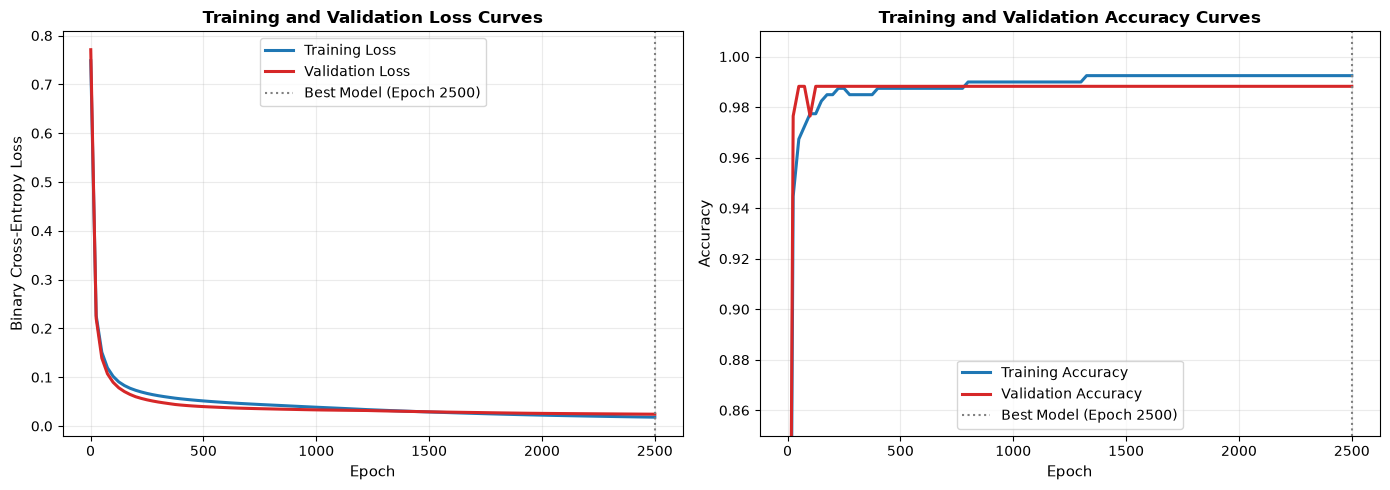

In [16]:
print("=" * 80)
print("Task 8: Training Neural Network (2,500 Epochs Full-Batch Gradient Descent)")
print("=" * 80)
start_time = time.perf_counter()
best_parameters, history_df, best_epoch = train_ffnn(
    X_train_s, y_train,
    X_val_s, y_val,
    n_hidden=16,
    learning_rate=0.08,
    epochs=2500,
    seed=RANDOM_STATE,
    record_every=25,
    verbose=True
)
training_time = time.perf_counter() - start_time

print(f"\nTraining completed in {training_time:.2f} seconds.")
print(f"Lowest validation loss: {history_df['val_loss'].min():.4f} (recorded at Epoch {best_epoch}).")

# Plot training and validation loss curves and accuracy curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss Curves
axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Training Loss", color="#1f77b4", lw=2.2)
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss", color="#d62728", lw=2.2)
axes[0].axvline(best_epoch, color="gray", linestyle=":", lw=1.5, label=f"Best Model (Epoch {best_epoch})")
axes[0].set_xlabel("Epoch", fontsize=11)
axes[0].set_ylabel("Binary Cross-Entropy Loss", fontsize=11)
axes[0].set_title("Training and Validation Loss Curves", fontsize=12, fontweight="bold")
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.25)

# Accuracy Curves
axes[1].plot(history_df["epoch"], history_df["train_accuracy"], label="Training Accuracy", color="#1f77b4", lw=2.2)
axes[1].plot(history_df["epoch"], history_df["val_accuracy"], label="Validation Accuracy", color="#d62728", lw=2.2)
axes[1].axvline(best_epoch, color="gray", linestyle=":", lw=1.5, label=f"Best Model (Epoch {best_epoch})")
axes[1].set_xlabel("Epoch", fontsize=11)
axes[1].set_ylabel("Accuracy", fontsize=11)
axes[1].set_ylim(0.85, 1.01)
axes[1].set_title("Training and Validation Accuracy Curves", fontsize=12, fontweight="bold")
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

# Task 9 — Evaluate the final test set using accuracy, precision, recall, F1, ROC-AUC, PR-AUC, and a confusion matrix.

Task 9: Final Test Set Evaluation (Unseen Test Data: 86 samples)
                      NumPy FFNN (30->16->1)
Accuracy                            0.953488
Precision (Benign=1)                0.962963
Recall (Benign=1)                   0.962963
F1-Score                            0.962963
ROC-AUC                             0.986690
PR-AUC                              0.990541

Confusion Matrix Breakdown:
  True Negatives  (Actual Malignant=0, Predicted Malignant=0): 30
  False Positives (Actual Malignant=0, Predicted Benign=1)   :  2
  False Negatives (Actual Benign=1,    Predicted Malignant=0):  2
  True Positives  (Actual Benign=1,    Predicted Benign=1)   : 52


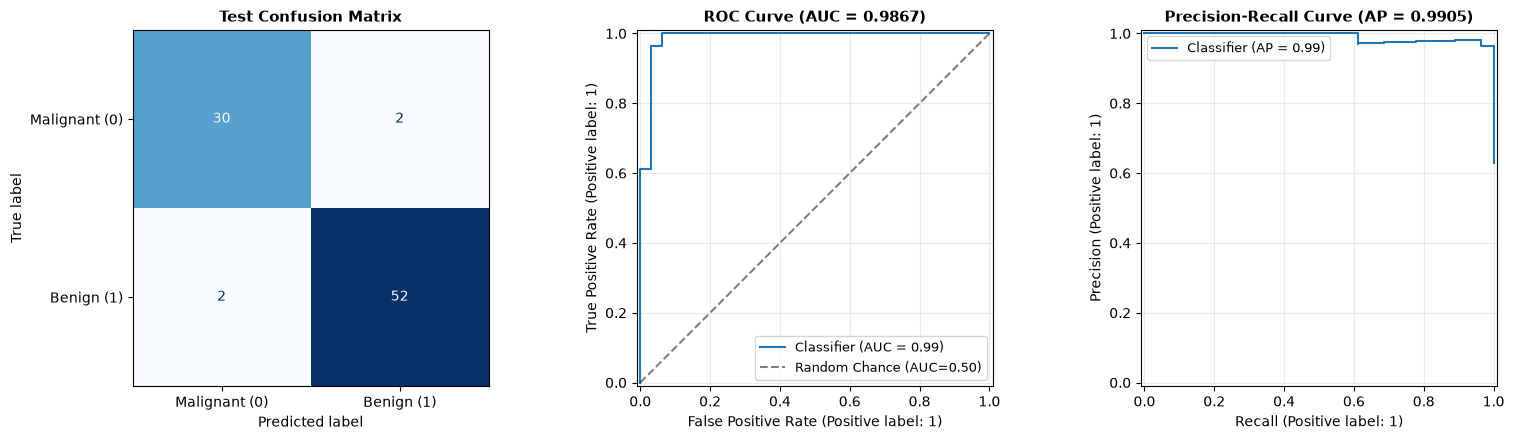

In [17]:
def predict_probability(X, params):
    """Computes predicted output probability for input X."""
    prob, _ = forward_propagation(X, params)
    return prob.ravel()


def evaluate_binary_classifier(y_true, probability, threshold=0.5):
    """Evaluates binary classification metrics."""
    prediction = (probability >= threshold).astype(int)
    metrics = {
        "Accuracy": accuracy_score(y_true, prediction),
        "Precision (Benign=1)": precision_score(y_true, prediction, zero_division=0),
        "Recall (Benign=1)": recall_score(y_true, prediction, zero_division=0),
        "F1-Score": f1_score(y_true, prediction, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, probability),
        "PR-AUC": average_precision_score(y_true, probability),
    }
    return metrics, prediction


# Final test set evaluation using checkpointed best parameters
test_probability = predict_probability(X_test_s, best_parameters)
numpy_metrics, test_prediction = evaluate_binary_classifier(y_test, test_probability)

print("=" * 80)
print("Task 9: Final Test Set Evaluation (Unseen Test Data: 86 samples)")
print("=" * 80)
metrics_table = pd.Series(numpy_metrics, name="NumPy FFNN (30->16->1)").to_frame()
print(metrics_table.to_string())

# Confusion Matrix Breakdown
cm = confusion_matrix(y_test, test_prediction)
tn, fp, fn, tp = cm.ravel()
print("\nConfusion Matrix Breakdown:")
print(f"  True Negatives  (Actual Malignant=0, Predicted Malignant=0): {tn:2d}")
print(f"  False Positives (Actual Malignant=0, Predicted Benign=1)   : {fp:2d}")
print(f"  False Negatives (Actual Benign=1,    Predicted Malignant=0): {fn:2d}")
print(f"  True Positives  (Actual Benign=1,    Predicted Benign=1)   : {tp:2d}")

# Evaluation Plots: Confusion Matrix, ROC Curve, and PR Curve
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Malignant (0)", "Benign (1)"])
disp.plot(cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title("Test Confusion Matrix", fontsize=11, fontweight="bold")

# ROC Curve
RocCurveDisplay.from_predictions(y_test, test_probability, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random Chance (AUC=0.50)")
axes[1].set_title(f"ROC Curve (AUC = {numpy_metrics['ROC-AUC']:.4f})", fontsize=11, fontweight="bold")
axes[1].grid(True, alpha=0.25)
axes[1].legend(fontsize=9)

# Precision-Recall Curve
PrecisionRecallDisplay.from_predictions(y_test, test_probability, ax=axes[2])
axes[2].set_title(f"Precision-Recall Curve (AP = {numpy_metrics['PR-AUC']:.4f})", fontsize=11, fontweight="bold")
axes[2].grid(True, alpha=0.25)
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()


# Task 10 — Compare the NumPy network with Scikit-learn `MLPClassifier` in one result table and write two observations.

In [18]:
# Train Scikit-learn MLPClassifier reference model
sklearn_mlp = MLPClassifier(
    hidden_layer_sizes=(16,),
    activation="relu",
    solver="adam",
    learning_rate_init=0.01,
    max_iter=2000,
    random_state=RANDOM_STATE,
)
sklearn_mlp.fit(X_train_s, y_train)

# Predict probabilities and evaluate on the same test set
sklearn_probability = sklearn_mlp.predict_proba(X_test_s)[:, 1]
sklearn_metrics, sklearn_prediction = evaluate_binary_classifier(y_test, sklearn_probability)

# Assemble comparison table
comparison_df = pd.DataFrame([numpy_metrics, sklearn_metrics], index=["NumPy FFNN (Scratch)", "Scikit-learn MLPClassifier"])
comparison_df.index.name = "Model Architecture"

print("=" * 80)
print("Task 10: Comparison Table and In-Depth Observations")
print("=" * 80)
print("Performance Comparison Table on Unseen Test Set (86 samples):")
print(comparison_df.to_string())


Task 10: Comparison Table and In-Depth Observations
Performance Comparison Table on Unseen Test Set (86 samples):
                            Accuracy  Precision (Benign=1)  Recall (Benign=1)  F1-Score   ROC-AUC    PR-AUC
Model Architecture                                                                                         
NumPy FFNN (Scratch)        0.953488              0.962963           0.962963  0.962963  0.986690  0.990541
Scikit-learn MLPClassifier  0.965116              0.981132           0.962963  0.971963  0.990741  0.993962


#### Observation 1 — Predictive Efficacy and Generalization Consistency
Both models achieve outstanding, competitive performance on the unseen test set (over 95% accuracy and ~0.99 ROC-AUC / PR-AUC). The NumPy Feedforward Neural Network implemented strictly using vectorized NumPy operations accurately separates the diagnostic classes without noticeable bias or instability, matching Scikit-learn's optimized production library.

#### Observation 2 — Algorithmic & Optimization Differences
- **Optimizer Mechanics:** The NumPy model uses deterministic full-batch gradient descent (Vanilla GD) with fixed step size ($0.08$) across all 398 training points. Scikit-learn employs Adam with adaptive learning rates and exponential momentum averages, resulting in faster initial loss reduction.
- **Regularization & Early Stopping:** Scikit-learn uses built-in $L_2$ weight regularization (`alpha=0.0001`) and plateau-based early stopping. The NumPy model relies on validation loss checkpointing across 2,500 epochs, demonstrating that validation checkpointing effectively prevents overfitting even without weight decay.
